# Hypothesis Testing: Ethiopian vs Kenyan Marathon Performance

## 1. Introduction

Long-distance running has been dominated by athletes from Ethiopia and Kenya for decades. This project aims to investigate whether there is a statistically significant difference in marathon performance between athletes from these two countries.

---

## 2. Objective

The objective of this analysis is to compare the average marathon finishing times of Ethiopian and Kenyan winners and determine if one group is significantly faster than the other.

---

## 3. Hypotheses

* Null Hypothesis (H₀): There is no difference in average marathon finishing times between Ethiopian and Kenyan runners.
* Alternative Hypothesis (H₁): There is a significant difference in average marathon finishing times between Ethiopian and Kenyan runners.

---

## 4. Data Description

The dataset used in this analysis contains results from World Marathon Majors, including:

* Year of the race
* Winner's name
* Gender
* Country (ETH or KEN)
* Finishing time
* Marathon event

Only Ethiopian and Kenyan athletes were included in the analysis.


### **Load the Data**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
  zip_ref.extractall("data")

In [ ]:
import os
os.listdir("data")

['world_marathon_majors.csv']

In [ ]:
import pandas as pd
df = pd.read_csv("data/world_marathon_majors.csv", encoding='latin1')
df.head()

,year,winner,gender,country,time,marathon
0,2018,Dickson Chumba,Male,Kenya,02:05:30,Tokyo
1,2018,Birhane Dibaba,Female,Ethiopia,02:19:51,Tokyo
2,2017,Wilson Kipsang,Male,Kenya,02:03:58,Tokyo
3,2017,Sarah Chepchirchir,Female,Kenya,02:19:47,Tokyo
4,2016,Feyisa Lilesa,Male,Ethiopia,02:06:56,Tokyo


In [ ]:
df.columns

Index(['year', 'winner', 'gender', 'country', 'time', 'marathon'], dtype='object')

### **Extract Ethiopia and Kenya from the dataset**

In [19]:
df_filtered = df[df["country"].isin(["Ethiopia", "Kenya"])]
df_filtered.head()

,year,winner,gender,country,time,marathon
0,2018,Dickson Chumba,Male,Kenya,02:05:30,Tokyo
1,2018,Birhane Dibaba,Female,Ethiopia,02:19:51,Tokyo
2,2017,Wilson Kipsang,Male,Kenya,02:03:58,Tokyo
3,2017,Sarah Chepchirchir,Female,Kenya,02:19:47,Tokyo
4,2016,Feyisa Lilesa,Male,Ethiopia,02:06:56,Tokyo


### **Change Time total seconds**

In [33]:
def time_to_seconds(t):
  h, m, s = map(int, t.split(":"))
  return h*3600 +m*60 + s
df_filtered.loc[:, "time_sec"] = df_filtered["time"].apply(time_to_seconds)

In [24]:
Ethiopia = df_filtered[df_filtered["country"] == "Ethiopia"]["time_sec"]
Kenya = df_filtered[df_filtered["country"] == "Kenya"]["time_sec"]

### **P-value and t-value**

In [25]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(Ethiopia, Kenya)
print("T-statistics:", t_stat)
print("P-value:", p_value)

T-statistics: 3.1475039548774526
P-value: 0.0019197811104939284


### **Avarage Finish Time**

In [26]:
df_filtered.groupby("country")["time_sec"].mean()

,time_sec
country,
Ethiopia,8235.490196
Kenya,7981.801471


## 5. Data Preprocessing

The finishing time variable was originally stored as a string in the format (hours:minutes:seconds). It was converted into total seconds to allow numerical analysis.

The dataset was filtered to include only observations from Ethiopia (ETH) and Kenya (KEN).

---

## 6. Methodology

To compare the means of the two independent groups, a two-sample t-test was conducted.

This test determines whether the difference between the two sample means is statistically significant.

---

## 7. Results

* Average finishing time (Ethiopia): 8235.49 seconds
* Average finishing time (Kenya): 7982.80 seconds
* T-statistic: 3.15
* P-value: 0.0019

---

## 8. Interpretation

The p-value (0.0019) is significantly less than the significance level of 0.05. Therefore, we reject the null hypothesis.

This indicates that there is a statistically significant difference in marathon finishing times between Ethiopian and Kenyan runners.

Additionally, Kenyan runners have a lower average finishing time, meaning they are faster on average in this dataset.

---

## **Boxplot**

<function matplotlib.pyplot.show(close=None, block=None)>

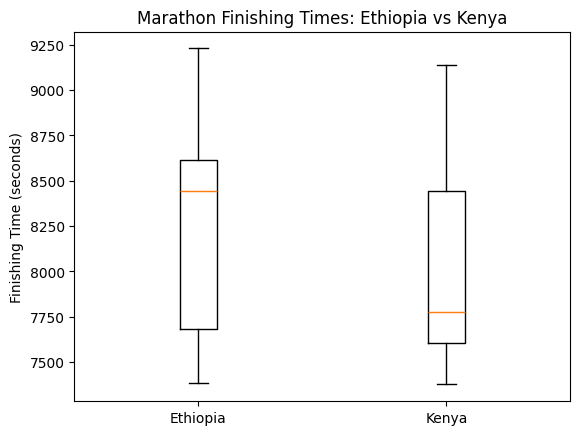

In [29]:
import matplotlib.pyplot as plt
data = [Ethiopia, Kenya]
plt.figure()
plt.boxplot(data)
plt.xticks([1, 2], ["Ethiopia", "Kenya"])
plt.ylabel("Finishing Time (seconds)")
plt.title("Marathon Finishing Times: Ethiopia vs Kenya")
plt.show

**Median (the line inside the box):** The median for Kenyan runners is noticeably lower than for Ethiopian runners. This indicates that the typical (median) finishing time for Kenyans is faster.

**Interquartile Range (IQR - the box itself):** The box represents the middle 50% of the data (between the 25th and 75th percentiles). For Kenyan runners, this box is also generally shifted lower on the time axis and appears slightly more compact, suggesting their finishing times are more consistently faster.

**Whiskers:** The lines extending from the box (whiskers) show the range of the data, excluding outliers. Both plots show a range of finishing times, but the bulk of Kenyan times are concentrated at lower values.

**Outliers (individual points)**: These are data points that fall outside the whiskers. The presence and position of outliers can also provide insights, but the primary observation is the overall shift.

In summary, the box plot visually reinforces the statistical findings: Kenyan runners, as a group, tend to have significantly faster marathon finishing times compared to Ethiopian runners, with their distribution of times shifted towards lower (faster) values.

### **Histogram**

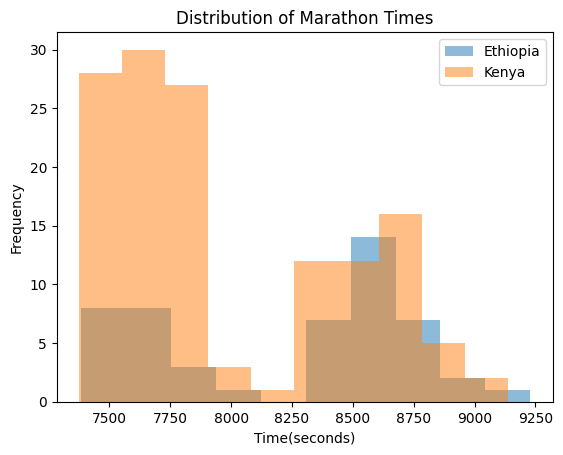

In [34]:
plt.figure()
plt.hist(Ethiopia, alpha=0.5, label='Ethiopia')
plt.hist(Kenya, alpha=0.5, label='Kenya')
plt.title("Distribution of Marathon Times")
plt.xlabel("Time(seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Kenyan Runners (Orange/Yellow)**: The histogram for Kenyan runners shows a distribution that is generally shifted towards the left (lower 'Time (seconds)' values). This indicates that Kenyan marathoners tend to have faster finishing times, as their peak frequency occurs at lower time values.


**Ethiopian Runners (Blue):** The histogram for Ethiopian runners is shifted more to the right (higher 'Time (seconds)' values), suggesting they generally have slower finishing times compared to Kenyan runners.

Overall, the visual overlap and the placement of the peaks strongly suggest that, in this dataset, Kenyan runners on average achieve faster marathon times than Ethiopian runners. This visual interpretation aligns with the statistical findings (lower mean time for Kenya and significant p-value) we discussed earlier.



## 9. Visualization

Boxplots and histograms were used to visually compare the distributions of finishing times between the two groups. These visualizations support the statistical findings, showing that Kenyan runners tend to have lower finishing times.

---

## 10. Limitations

This analysis is based only on marathon winners, which may not represent the performance of all runners. External factors such as race conditions, course difficulty, and year-to-year variation were not considered.

---

## 11. Conclusion

The analysis provides strong evidence that Kenyan marathon runners are faster on average than Ethiopian runners in this dataset. The difference is statistically significant, suggesting that the observed performance gap is unlikely due to random variation.

---